# Рекомендация товаров в электронной коммерции

Нашей целью в данном проекте будет разработать рекомендательную систему, коорая будет рекомендовать товар, который пользователь добавит в корзину.

Прпишем необходимые импорты и константы.

In [9]:
import os
from tqdm import tqdm
from tqdm.auto import tqdm
from datetime import datetime

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random

import mlflow

import scipy
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from implicit.als import AlternatingLeastSquares
from catboost import CatBoostClassifier, Pool

from dotenv import load_dotenv
import boto3

In [2]:
tqdm.pandas()

In [3]:
DATA_FOLDER = '../data'
RECOMENDATION_FOLDER = '../recommendations'
GRAPHS_FOLDER = '../graphs'
MODELS_FOLDER = '../models'

os.makedirs(DATA_FOLDER, exist_ok=True)
os.makedirs(RECOMENDATION_FOLDER, exist_ok=True)
os.makedirs(GRAPHS_FOLDER, exist_ok=True)
os.makedirs(MODELS_FOLDER, exist_ok=True)

Инициализируем MLFlow

In [4]:
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = "recomendation_ec"
REGISTRY_MODEL_NAME = "recomendation_ec_model_yaroslav_knyazev"

os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")

In [5]:
mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

Создадим функцию для работы с S3

In [6]:
load_dotenv()
AWS_ACCESS_KEY_ID = os.environ.get('AWS_ACCESS_KEY_ID')
AWS_SECRET_ACCESS_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY')
S3_BUCKET_NAME = os.environ.get('S3_BUCKET_NAME')

S3_SERVICE_NAME = 's3'
S3_ENDPOINT_URL = 'https://storage.yandexcloud.net'

In [7]:
def get_session():
    session = boto3.session.Session()

    return session.client(
        service_name=S3_SERVICE_NAME,
        endpoint_url=S3_ENDPOINT_URL,
        aws_access_key_id=AWS_ACCESS_KEY_ID,
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY
    )

Сразу загрузим сырые данные в S3, чтобы в дальнейшем к ним могли обращаться другие севрисы.

In [8]:
s3 = get_session()

s3.upload_file(f'{DATA_FOLDER}/events.csv', S3_BUCKET_NAME, 'recsys_ec/data/raw/events.csv')
s3.upload_file(f'{DATA_FOLDER}/item_properties_part1.csv', S3_BUCKET_NAME, 'recsys_ec/data/raw/item_properties_part1.csv')
s3.upload_file(f'{DATA_FOLDER}/item_properties_part2.csv', S3_BUCKET_NAME, 'recsys_ec/data/raw/item_properties_part2.csv')
s3.upload_file(f'{DATA_FOLDER}/category_tree.csv', S3_BUCKET_NAME, 'recsys_ec/data/raw/category_tree.csv')

Зафиксируем сиды

In [10]:
seed_val = 159
random.seed(seed_val)
np.random.seed(seed_val)

## EDA

Загрузим и проанализируем исходные данные

### Events

Загрузим и посмотрим на данные в таблице events

In [11]:
events = pd.read_csv(f'{DATA_FOLDER}/events.csv')
events.sample(5)

,timestamp,visitorid,event,itemid,transactionid
26317,1433282674939,1246307,view,448713,NaN
1803826,1432069183265,700737,view,440100,NaN
2742328,1438397995829,705834,view,93001,NaN
202249,1433962025742,1231805,view,228974,NaN
2102402,1435971700031,400860,view,134288,NaN


In [12]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


В таблице содержатся следующие столбцы:
- timestamp — временная метка события,
- visitorid — идентификатор пользователя,
- event — событие (просмотр, добавление в корзину, покупка),
- itemid — идентификатор товара,
- transactionid — идентификатор транзакции (покупки).

Посмотрим наличие пропусков в данных.

In [13]:
events.isna().sum()

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

В таблице видны следующие проблемы:
- дата приведена в формате timestamp её нужно преобразовать к обычному виду;
- в столбце transactionid много пропусков, но это связано с тем, что id транзакции будет только у покупок, а у нас есть информация по разным действиям пользователя, поэтому данный момент эта информация нам не нужна и мы можем удалить данный столбец.

Отсортируем события по пользователю, времени и номеру товара

In [14]:
events = events.sort_values(['visitorid', 'timestamp', 'itemid'])

Преобразуем дату

In [15]:
events['date'] = events['timestamp'].progress_apply(lambda x: datetime.fromtimestamp(x/1000).date())

100%|██████████| 2756101/2756101 [00:02<00:00, 1035892.79it/s]


Удалим ненужные столбцы

In [16]:
events = events.drop(['transactionid'], axis=1)

In [17]:
event_per_day = events.groupby(['date', 'event'], as_index=False).agg(user_count=("visitorid", "count"))

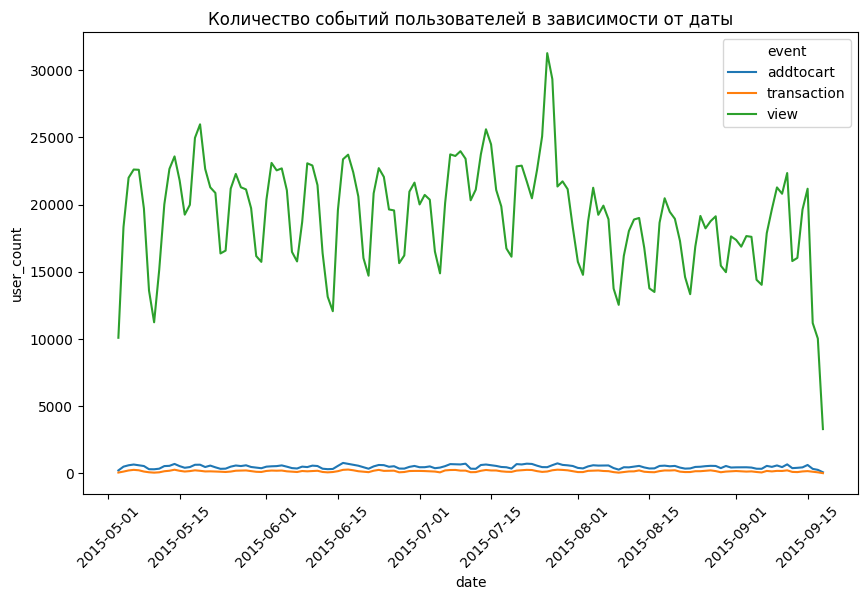

In [21]:
plt.figure(figsize=(10,6))
ax = sns.lineplot(data=event_per_day,
             x='date',
             y='user_count',
             hue='event'
             )
ax.tick_params(axis='x', rotation=45)
ax.set_title('Количество событий пользователей в зависимости от даты')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'events_per_date'))

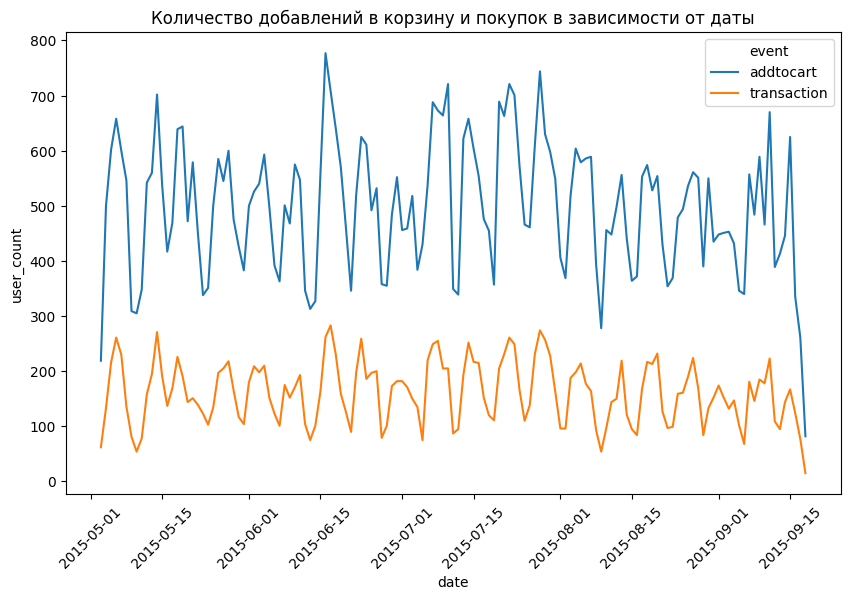

In [22]:
plt.figure(figsize=(10,6))
ax = sns.lineplot(data=event_per_day.loc[event_per_day['event'].isin(['addtocart', 'transaction'])],
             x='date',
             y='user_count',
             hue='event'
             )
ax.tick_params(axis='x', rotation=45)
ax.set_title('Количество добавлений в корзину и покупок в зависимости от даты')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'addtocart_and_transaction_per_date'))

Из графика можно сделать следующие вывод:
- просмотры, добавления в корзину и продажы имеют некую сезонность (пики примерно два дня в неделю);
- то, что человек просмотрит товар не значит, что он его купит (просмотров на порядки больше);
- добавление товара в корзину не означает покупку товара;
- после 2015-09-15 наблюдается сильное падение количества взаимодействий (причина неизвестна, но эти данные лучше удалить).

Удалим информацию о событиях после 2015-09-15

In [23]:
events = events.loc[events['date']<=datetime.strptime('2015-09-15', '%Y-%m-%d').date()]
events = events.reset_index(drop=True)

del event_per_day

Посмотрим как распределены просмотры, добавления в корзину и покупки среди пользователей (среднее количество в активный день, т.е. будум учитывать только те дни, когда пользователеь был на платформе)

In [24]:
user_events = pd.pivot_table(events, 
                            index=['visitorid', 'date'], 
                            columns=['event'], 
                            values='itemid', 
                            aggfunc='count').reset_index(drop=False)

user_events = user_events.groupby('visitorid').agg(
    view=('view', 'mean'),
    addtocart=('addtocart', 'mean'),
    transaction=('transaction', 'mean')
)

user_events.head()

,view,addtocart,transaction
visitorid,,,
0,3.0,NaN,NaN
1,1.0,NaN,NaN
2,8.0,NaN,NaN
3,1.0,NaN,NaN
5,1.0,NaN,NaN


Посмотрим на количество пропусков в кадлом из столбце

In [25]:
user_events.isna().sum()

view              3345
addtocart      1357643
transaction    1383399
dtype: int64

Как и ожидалось среди добавлений в корзину и покупками есть много пропусков (товар посмотрели, но не добавили в корзину). Однако есть пропуски и среди тех, кто добавил товар в корзину или купил без просмотров (что странно, поскольку перед добавлением товар в любом случае необходимо посмотреть). Посмотрим на тех, у кого есть порпуски в просмотрах. 

In [26]:
user_events.loc[user_events['view'].isna()].sample(5)

,view,addtocart,transaction
visitorid,,,
44507,NaN,1.0,NaN
170927,NaN,2.0,NaN
424163,NaN,1.0,NaN
1172524,NaN,1.0,NaN
975692,NaN,1.0,NaN


Возможно кто-то добавляет товары сразу в корзину, а потом решает купить или нет. Но при этом покупки в данной категории пользователей крайне редки (возможно стоит сделать отдельный признак для данной категории пользователей).

Построим гистограммы чтобы определить как распределены действия среди пользователей.

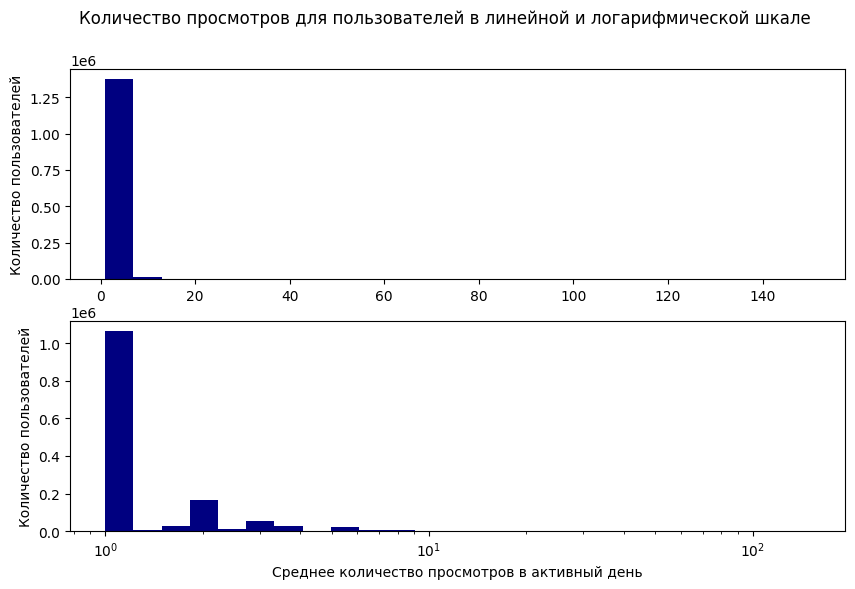

In [27]:
plt.figure(figsize=(10, 6))
plt.suptitle('Количество просмотров для пользователей в линейной и логарифмической шкале')
plt.subplot(211)
hist, bins, _ = plt.hist(user_events['view'], bins=25, color='navy')
plt.ylabel('Количество пользователей')

logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
plt.subplot(212)
plt.hist(user_events['view'], bins=logbins, color='navy')
plt.xscale('log')
plt.xlabel('Среднее количество просмотров в активный день')
plt.ylabel('Количество пользователей')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'view_per_user'))

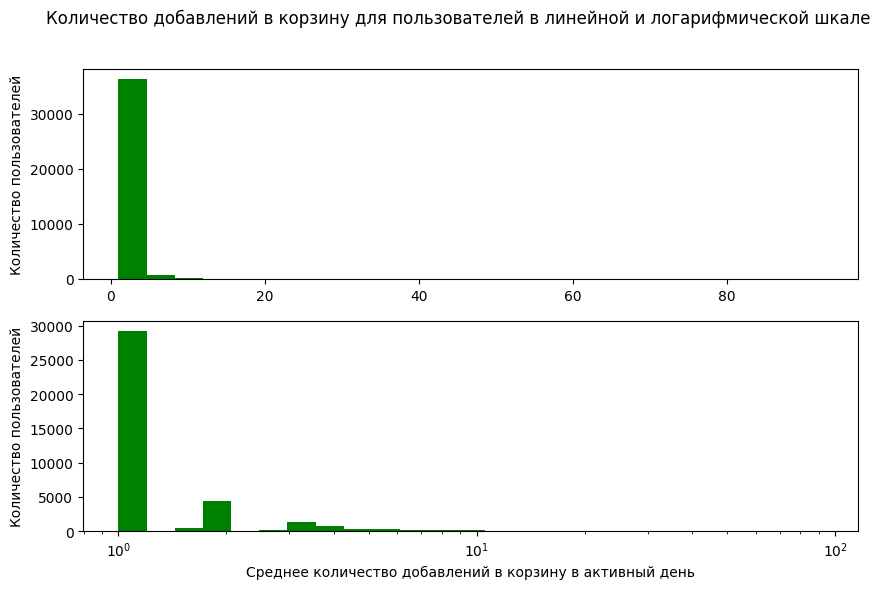

In [28]:
plt.figure(figsize=(10, 6))
plt.suptitle('Количество добавлений в корзину для пользователей в линейной и логарифмической шкале')
plt.subplot(211)
hist, bins, _ = plt.hist(user_events['addtocart'], bins=25, color='g')
plt.ylabel('Количество пользователей')

logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
plt.subplot(212)
plt.hist(user_events['addtocart'], bins=logbins, color='g')
plt.xscale('log')
plt.xlabel('Среднее количество добавлений в корзину в активный день')
plt.ylabel('Количество пользователей')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'addtocart_per_user'))

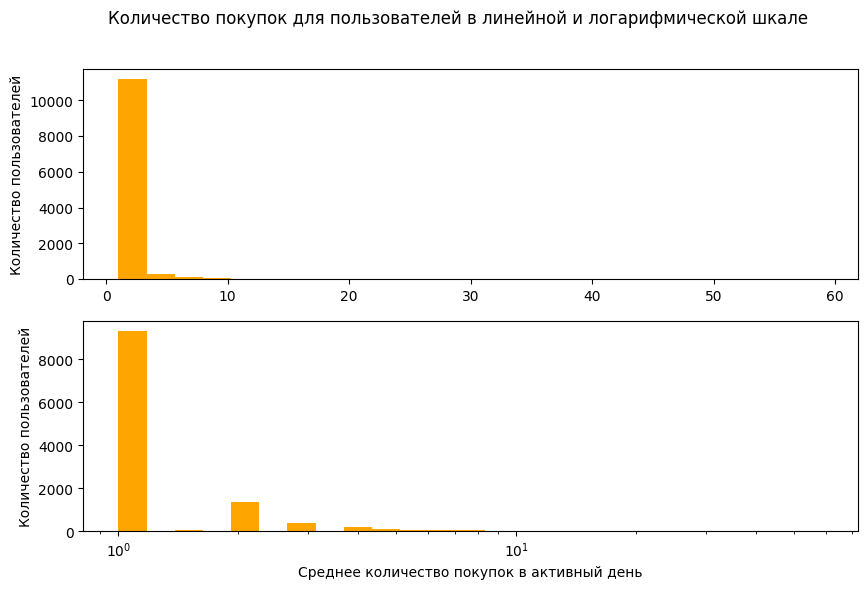

In [29]:
plt.figure(figsize=(10, 6))
plt.suptitle('Количество покупок для пользователей в линейной и логарифмической шкале')
plt.subplot(211)
hist, bins, _ = plt.hist(user_events['transaction'], bins=25, color='orange')
plt.ylabel('Количество пользователей')

logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
plt.subplot(212)
plt.hist(user_events['transaction'], bins=logbins, color='orange')
plt.xscale('log')
plt.xlabel('Среднее количество покупок в активный день')
plt.ylabel('Количество пользователей')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'transaction_per_user'))

По данным видно, что у нас есть выбросы по всем трём категориям (есть пользователи, которые совершают очень много покупок, просматривают очень больщое количество товаров и т.д.). И либо это уникальные пользователи, либо боты, но в любом случае их лучше не рассматривать вместе со всеми и отбросить как выбросы, чтобы модель корректно отрабатывала на большинстве пользователей.

Для каждой пары пользователь / товар укажем сколько и каких взаимодействий был и вынесем каждое взаимодействие в отдельный столбец

In [30]:
def get_events_before(df: pd.DataFrame, column_action: str, column_value: str) -> pd.DataFrame:
    df = df.copy(deep=True)
    list_columns_action = events[column_action].unique()

    # ставим флаг, что событие произошло
    df['flag'] = 1
    # разворачиваем таблицу в широкий вариант
    pivot_events = df.pivot_table(index=['visitorid', column_value, 'timestamp'],
                                columns=column_action,
                                values='flag',
                                fill_value=0).reset_index(drop=False)
    
    # группируем и рассчитвыавем кумулитивную сумму
    pivot_events[list_columns_action] = pivot_events.groupby(['visitorid', column_value])[list_columns_action].cumsum()
    pivot_events[list_columns_action] = pivot_events[list_columns_action].astype(int)

    # переименновываем столбцы, удаляем флаг и объединяем датасеты
    pivot_events = pivot_events.rename(columns={col: f'{col}_{column_value}_before' for col in list_columns_action})    
    df = df.drop('flag', axis=1)
    df = df.merge(pivot_events, on=['visitorid', column_value, 'timestamp'], how='left')
    return df

In [31]:
events = get_events_before(events, 'event', 'itemid')

Посмотрим результат на примере одной пары пользователь-товар у которых была достаточно большая история взаимодействий

In [32]:
events[(events['visitorid']==1403769) & (events['itemid']==312728)]

,timestamp,visitorid,event,itemid,date,addtocart_itemid_before,transaction_itemid_before,view_itemid_before
2723425,1431631579571,1403769,view,312728,2015-05-14,0,0,1
2723426,1431631940289,1403769,view,312728,2015-05-14,0,0,2
2723427,1431632687292,1403769,view,312728,2015-05-14,0,0,3
2723434,1431651045380,1403769,view,312728,2015-05-15,0,0,4
2723436,1431722468262,1403769,view,312728,2015-05-15,0,0,5
2723437,1431722899525,1403769,view,312728,2015-05-15,0,0,6
2723438,1431722957252,1403769,view,312728,2015-05-15,0,0,7
2723439,1431723462862,1403769,view,312728,2015-05-15,0,0,8
2723480,1432655299494,1403769,view,312728,2015-05-26,0,0,9
2723481,1432667696439,1403769,view,312728,2015-05-26,0,0,10


Всё отработало корректно. Теперь сгрупируем по пользователям, чтобы получить среднее значение для каждого из них.

In [33]:
user_events = events.groupby('visitorid').agg(
    view_before=('view_itemid_before', 'mean'),
    addtocart_before=('addtocart_itemid_before', 'mean'),
    transaction_before=('transaction_itemid_before', 'mean')
)

user_events.head()

,view_before,addtocart_before,transaction_before
visitorid,,,
0,1.000,0.0,0.0
1,1.000,0.0,0.0
2,1.625,0.0,0.0
3,1.000,0.0,0.0
5,1.000,0.0,0.0


Добавим столбцы, уоторые будут показывать отношение добавление в корзину на количество просмотров и совершение покупок на добавление в корзину

In [34]:
user_events['ratio_addtocart'] = user_events['addtocart_before'] / user_events['view_before']
user_events['ratio_transaction'] = user_events['transaction_before'] / user_events['addtocart_before']

Построим графики и проанализируем их. При этом не будем выводить значения равные 0 (когда не было добавлений в корзину и были только просмотры) и равные бесконечности (когда были только добавления в корзину).

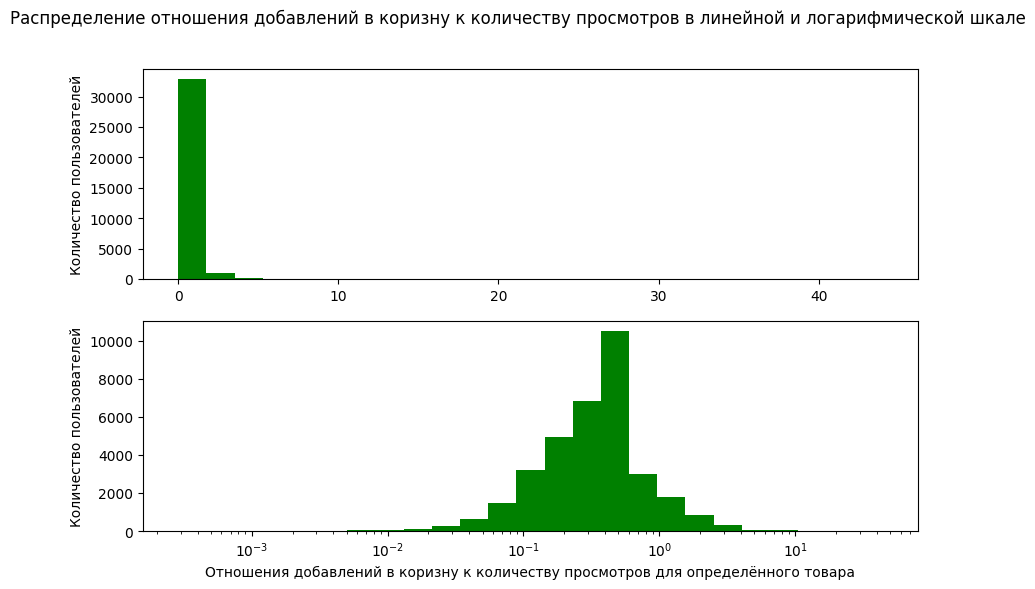

In [35]:
plt.figure(figsize=(10, 6))
plt.suptitle('Распределение отношения добавлений в коризну к количеству просмотров в линейной и логарифмической шкале')
plt.subplot(211)
data_for_hist = user_events.loc[~(user_events['ratio_addtocart'] == np.inf) & 
                                (user_events['ratio_addtocart'] != 0), 'ratio_addtocart']
hist, bins, _ = plt.hist(data_for_hist, bins=25, color='g')
plt.ylabel('Количество пользователей')

logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
plt.subplot(212)
plt.hist(data_for_hist, bins=logbins, color='g')
plt.xscale('log')
plt.xlabel('Отношения добавлений в коризну к количеству просмотров для определённого товара')
plt.ylabel('Количество пользователей')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'ratio_addtocart'))

Как видим в среднем данное отношение стремится к 0.3 - 0.4. Т.е. если человек просмоатривает товар перед добавлением в корзину, то делает это 2-3 раза. При этом правая часть распределения явно меньше чем левая, значит большиснтво пользователей, как правиило смотрят товар хотя бы несколько раз прежде чем добавить в корзину.

Построим аналогичный график для отношение совершение покупки / добавление в корзину.

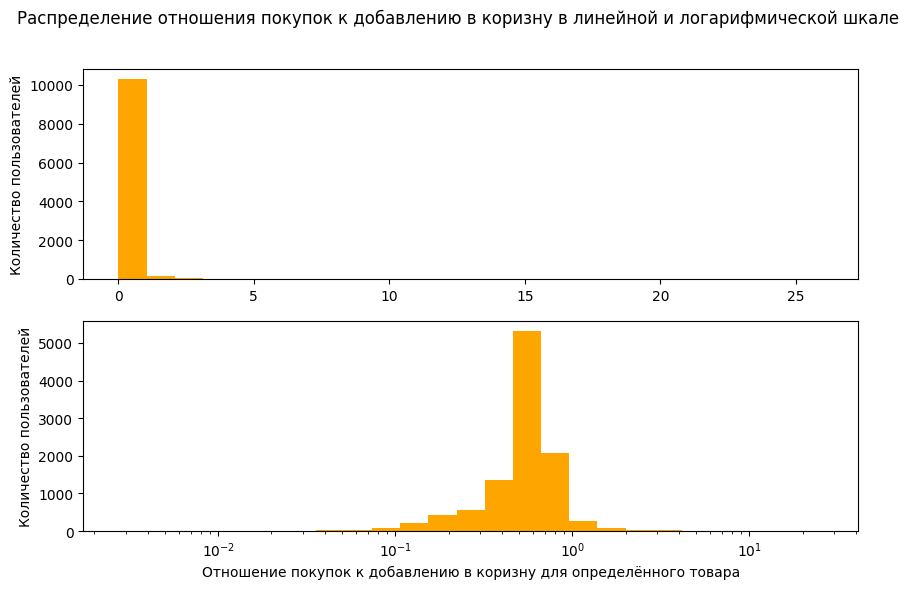

In [36]:
plt.figure(figsize=(10, 6))
plt.suptitle('Распределение отношения покупок к добавлению в коризну в линейной и логарифмической шкале')
plt.subplot(211)
data_for_hist = user_events.loc[~(user_events['ratio_transaction'] == np.inf) & 
                                (user_events['ratio_transaction'] != 0), 'ratio_transaction']
hist, bins, _ = plt.hist(data_for_hist, bins=25, color='orange')
plt.ylabel('Количество пользователей')

logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
plt.subplot(212)
plt.hist(data_for_hist, bins=logbins, color='orange')
plt.xscale('log')
plt.xlabel('Отношение покупок к добавлению в коризну для определённого товара')
plt.ylabel('Количество пользователей')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'ratio_transaction'))

Данное распределение имеет пик в районе 0.5 - 0.6, но в отличие от предыдущего распредления правая часть больше левой и можно сделать вывод, что большинство пользователей после добавления товара в корзину совершают покупку, хотя есть достаточно больщая часть, которая этого не делает.

### item_properties

Посмотрим на таблицу с харктеристиками товаров, данная таблица содержит следующие столбцы:
- timestamp — временная метка добавления свойства,
- itemid — идентификатор товара,
- property — свойство товара,
- value — значение свойства.

Данная таблица состоит из двух частей, поэтому сразу откроим их и объединим.

In [37]:
items = pd.concat([pd.read_csv(f'{DATA_FOLDER}/item_properties_part1.csv'),
                   pd.read_csv(f'{DATA_FOLDER}/item_properties_part2.csv')
                   ], axis=0).sort_values(by=['itemid', 'property', 'timestamp']).reset_index(drop=True)

items.head()

,timestamp,itemid,property,value
0,1433646000000,0,1036,1276750
1,1433041200000,0,1056,n3.168 1144008
2,1433646000000,0,11,n15360.000 628176 n12288.000
3,1433646000000,0,112,679677
4,1433041200000,0,127,1168476


Проверим наличие дубликатов по товару и категории

In [38]:
items[['itemid', 'property']].duplicated().sum()

8272088

Удалим дубликаты оставив только последнее значение для каждого свойства.

In [39]:
items = items.drop_duplicates(subset=['itemid', 'property'], keep='last')

Развернём нашу таблицу в широкий вариант

In [40]:
items = items.pivot(index='itemid', 
                    columns='property', 
                    values='value').reset_index(drop=False)
items.sample(5, random_state=123)

property,itemid,0,1,10,100,1000,1001,1002,1003,1004,...,992,993,994,995,996,997,998,999,available,categoryid
262532,293808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,23
203924,228190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1680
322130,360523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1084
15369,17210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,671
175362,196167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1051


У нас больше 1100 признаков и заполнены и много пропусков в данных. Посмотрим долю пропусков для каждого признака и отобразим их на гистограмме

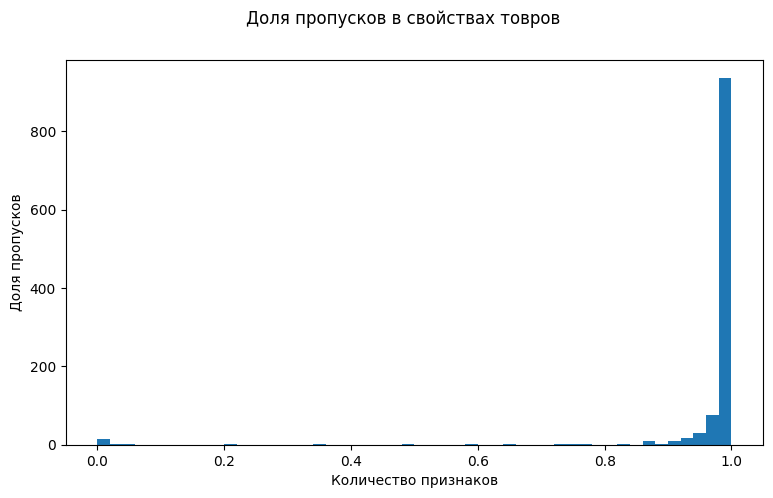

In [41]:
plt.figure(figsize=(9, 5))
plt.suptitle('Доля пропусков в свойствах товров')
plt.hist(items.isna().sum() / len(items), bins=50)
plt.ylabel('Доля пропусков')
plt.xlabel('Количество признаков')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'null_in_property'))

У нас много признаков с долей пропусков больше 0.9. Для адекватной работы с данными оставим только те столбцы, где доля пропусков меньше 0.1

In [42]:
not_na_columns = items.isna().sum()[(items.isna().sum() / len(items) < 0.1).values].index.to_list()

In [43]:
items = items[not_na_columns]
items.sample(5, random_state=123)

property,itemid,112,159,202,283,364,6,678,764,776,790,839,888,917,available,categoryid
262532,293808,679677,519769,1128997,1155113 150169 719466 193899 1128997 1155113 1...,163137,1155113 150169 719466,193899,1285872,1174467,n16320.000,193899,1128997,1128997,1,23
203924,228190,679677,519769,89423,305351 322391 1120576 114320 89423,841712,305351 322391,1120576 114320,1285872,383785,n77880.000,1120576 114320,89423 89423,89423,1,1680
322130,360523,679677,519769,n22716.000,188678 1095950 58077 84045 n22716.000 49647 95...,954139,188678 1095950 58077 150169 22871,84045,1285872,276226,n13800.000,84045,n22716.000,n120602688.000,0,1084
15369,17210,679677,519769,1085930,640322 512114 1085930 827388 916300 999945 512...,290854,640322,512114,1285872,1167737,n6012.000,512114,1085930 n240.000 424566 1297729 n36.000 350726...,n2670840.000,0,671
175362,196167,679677,519769,1286538,977762 1276616 1286538,282245,977762,1276616,1285872,413485,n390960.000,1276616,1286538,617757,0,1051


У нас осталось гораздо меньше столбцов, но не понятно что обозначают сами столбцы (кроме available и categoryid). Любой из признаков может оказаться категориальным и просто содержать целочисленный ключ к таблице с категориями или какким-то вещественным параметром. Посмотрим долю уникальныъ значений для каждого из столбцов.

In [44]:
ratio_unique = []
columns_name = []
for col in items.columns:
    ratio_unique.append(len(items[col].unique()) / len(items))
    columns_name.append(f'{col} ({len(items[col].unique())} уник. зн.)')

df_unique_col = pd.DataFrame({
    'columns_name': columns_name,
    'ratio_unique': ratio_unique
})

df_unique_col = df_unique_col.sort_values('ratio_unique')

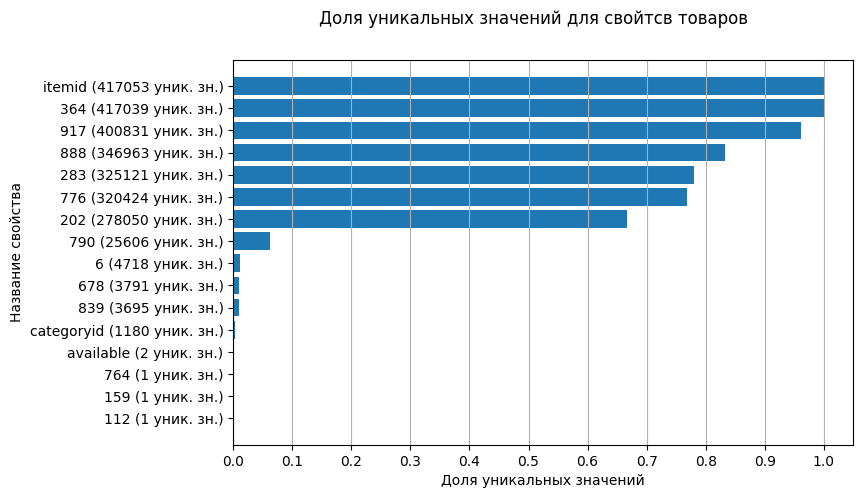

In [45]:
plt.figure(figsize=(8, 5))
plt.suptitle('Доля уникальных значений для свойтсв товаров')
plt.barh(y=df_unique_col['columns_name'], width=df_unique_col['ratio_unique'])
plt.xticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='x')
plt.xlabel('Доля уникальных значений')
plt.ylabel('Название свойства')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'unique_property'))

Поскольку у нас нет конкретного описанияп по свойствам, то оставим только те, которые подходят под категориальные признаки и которые в дальнейшем можно будет использовать для анализа схожести товаров. При этом будем использовать признаки с малым значением уникальности, чтобы в дальнейшем не получить сверх разреженную матрицу. Так же не будем использовать константные столбцы (те у которых 1 уникалное значение для всех). И столбец доступности товара (он нам пригодится в другом виде, чтобы не рекомендовать отсутствующие товары). В результате получим слеудющий список столбцов.

In [46]:
correct_columns = [
    'itemid',
    '6',
    '678',
    '839',
    'categoryid'
]

items = items[correct_columns]
items.head()

property,itemid,6,678,839,categoryid
0,0,66094,372274,372274,209
1,1,1020281,1204938,1204938,1114
2,2,NaN,147366 343631,147366 343631,1305
3,3,1305767,327918,327918,1171
4,4,588652 1091491,508476,508476,1038


Стоит отмети, что столбцы 6, 678, 839 представляютсобой списки в виде строк и их нужно будет в дальнейшем преобразовать

### category_tree

Данная таблица состоит из двух столбцов: «родительская категория» и «дочерняя категория» и позволяет расширить свойства товаров. Посмотрим на неё.

In [47]:
category_tree = pd.read_csv(f'{DATA_FOLDER}/category_tree.csv')
category_tree.head()

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [48]:
category_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


У нас есть пропуск в parentid, т.е. не для всех категоирй есть родительские. 

Посмотрим, скольким родительским категориям может соответствовать одна категория.

In [49]:
category_tree.groupby('categoryid')['parentid'].agg('count').value_counts()

parentid
1    1644
0      25
Name: count, dtype: int64

Как видим у нас для каждой категории есть только одна родительская категория.

Рассмотрим обратную ситуацию: сколько категорий входит в однй родительскую.

In [50]:
category_tree.groupby('parentid')['categoryid'].agg('count')

parentid
8.0        5
9.0        6
14.0       7
19.0       1
20.0       5
          ..
1687.0    17
1691.0     2
1692.0     3
1696.0     3
1698.0     7
Name: categoryid, Length: 362, dtype: int64

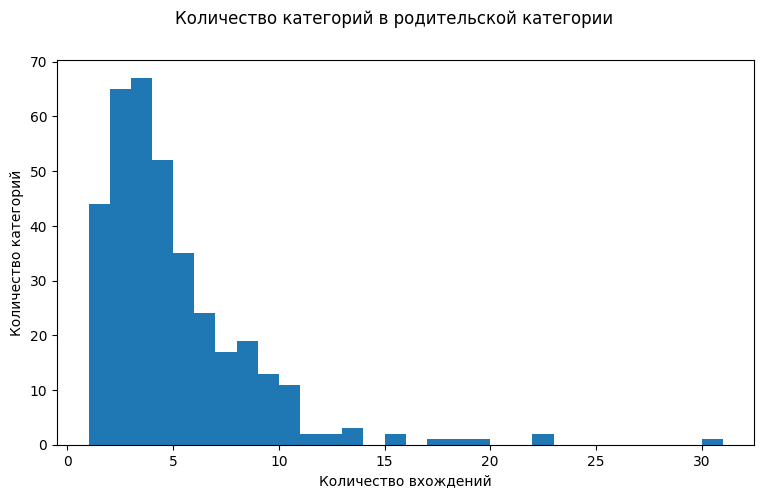

In [51]:
plt.figure(figsize=(9, 5))
plt.suptitle('Количество категорий в родительской категории')
plt.hist(category_tree.groupby('parentid')['categoryid'].agg('count'), bins=30)
plt.ylabel('Количество категорий')
plt.xlabel('Количество вхождений')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'categoryid_in_parentid'))

Как видим в основном, в одну родительскую категорию входит около трёх категорий более низкого уровня. Родительские категории для более чем 10 обычных категорий встречаются очень редко.

Добавим родительскую категорию в таблицу с товарами.

In [52]:
items['categoryid'] = items['categoryid'].astype(int)
items = items.merge(category_tree, on='categoryid', how='left')

Присоединим получившуюся информацию по товарам к датасету с событиями.

In [53]:
events = events.merge(items, on='itemid', how='left')
events.head()

,timestamp,visitorid,event,itemid,date,addtocart_itemid_before,transaction_itemid_before,view_itemid_before,6,678,839,categoryid,parentid
0,1442004589439,0,view,285930,2015-09-11,0,0,1,250259 309243 260167 150169 1149392,1029744,1029744,1188.0,1497.0
1,1442004759591,0,view,357564,2015-09-11,0,0,1,250259 1037547,910491,910491,256.0,1257.0
2,1442004917175,0,view,67045,2015-09-11,0,0,1,250259 1037547,910491,910491,333.0,1497.0
3,1439487966444,1,view,72028,2015-08-13,0,0,1,887448 174342,820477,820477,1192.0,955.0
4,1438969904567,2,view,325215,2015-08-07,0,0,1,36842,295499,295499,299.0,73.0


Добавим столбцы по взаимодействию пользователя с определённой категорией

In [54]:
events = get_events_before(events, 'event', 'categoryid')

Сгруппируем значения для каждого пользователя.

In [55]:
user_events = events.groupby('visitorid').agg(
    view_before=('view_categoryid_before', 'mean'),
    addtocart_before=('addtocart_categoryid_before', 'mean'),
    transaction_before=('transaction_categoryid_before', 'mean')
)

user_events.head()

,view_before,addtocart_before,transaction_before
visitorid,,,
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,3.0,0.0,0.0
3,1.0,0.0,0.0
5,1.0,0.0,0.0


In [56]:
user_events['ratio_addtocart'] = user_events['addtocart_before'] / user_events['view_before']
user_events['ratio_transaction'] = user_events['transaction_before'] / user_events['addtocart_before']

Построим графики

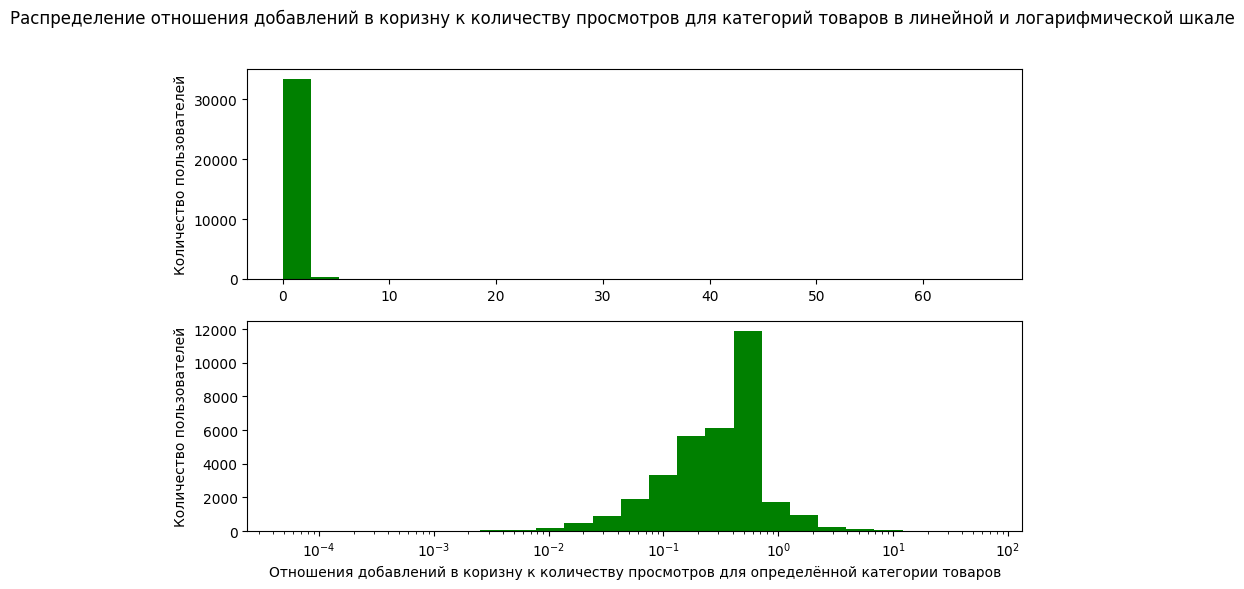

In [57]:
plt.figure(figsize=(10, 6))
plt.suptitle('Распределение отношения добавлений в коризну к количеству просмотров для категорий товаров в линейной и логарифмической шкале')
plt.subplot(211)
data_for_hist = user_events.loc[~(user_events['ratio_addtocart'] == np.inf) & 
                                (user_events['ratio_addtocart'] != 0), 'ratio_addtocart']
hist, bins, _ = plt.hist(data_for_hist, bins=25, color='g')
plt.ylabel('Количество пользователей')

logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
plt.subplot(212)
plt.hist(data_for_hist, bins=logbins, color='g')
plt.xscale('log')
plt.xlabel('Отношения добавлений в коризну к количеству просмотров для определённой категории товаров')
plt.ylabel('Количество пользователей')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'ratio_addtocart_category'))

Для данного распределения пик приходится ориентировочно на значения 0.5 - 0.6 при этом мы имеем массивный левый хвост, а значит пользователи часто просматривают схожие категории товаров, прежде чем добавить его в корзину.

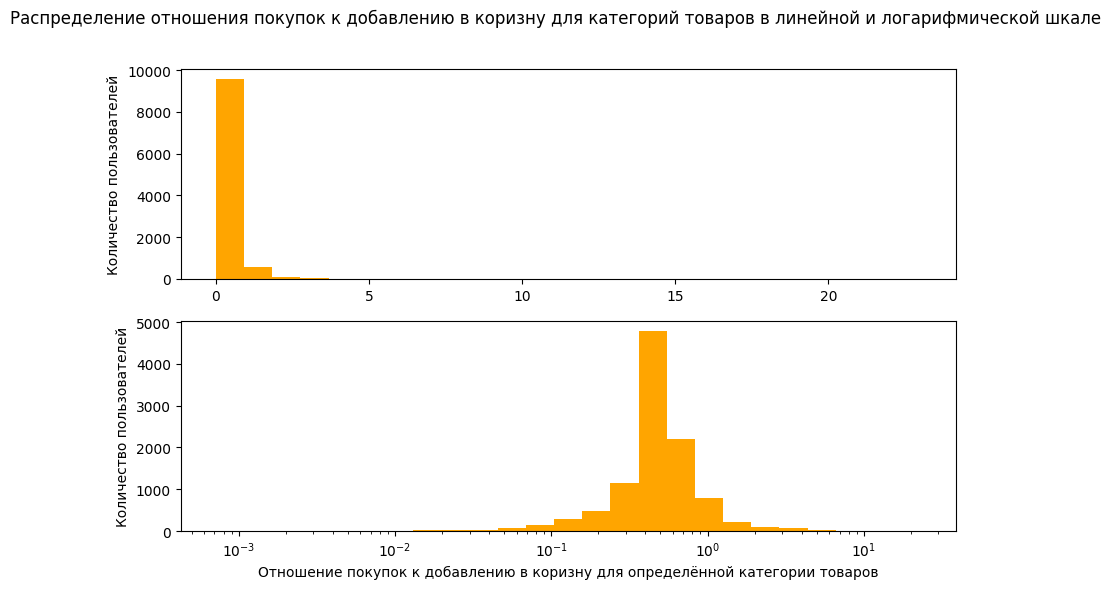

In [58]:
plt.figure(figsize=(10, 6))
plt.suptitle('Распределение отношения покупок к добавлению в коризну для категорий товаров в линейной и логарифмической шкале')
plt.subplot(211)
data_for_hist = user_events.loc[~(user_events['ratio_transaction'] == np.inf) & 
                                (user_events['ratio_transaction'] != 0), 'ratio_transaction']
hist, bins, _ = plt.hist(data_for_hist, bins=25, color='orange')
plt.ylabel('Количество пользователей')

logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
plt.subplot(212)
plt.hist(data_for_hist, bins=logbins, color='orange')
plt.xscale('log')
plt.xlabel('Отношение покупок к добавлению в коризну для определённой категории товаров')
plt.ylabel('Количество пользователей')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'ratio_transaction_category'))

Распределение имеет схожий вид как и распределение для товаров, хотя стало больше значений в районе 1, следовательно можно сделать вывод, что есть категория пользователей, которые накидываютв корзину схожие товары, а потом выбирают один.

Проделаем схожую работу для родительской категории.

In [59]:
events = get_events_before(events, 'event', 'parentid')


user_events = events.groupby('visitorid').agg(
    view_before=('view_parentid_before', 'mean'),
    addtocart_before=('addtocart_parentid_before', 'mean'),
    transaction_before=('transaction_parentid_before', 'mean')
)

user_events.head()

,view_before,addtocart_before,transaction_before
visitorid,,,
0,1.333333,0.0,0.0
1,1.000000,0.0,0.0
2,4.500000,0.0,0.0
3,1.000000,0.0,0.0
5,1.000000,0.0,0.0


In [60]:
user_events['ratio_addtocart'] = user_events['addtocart_before'] / user_events['view_before']
user_events['ratio_transaction'] = user_events['transaction_before'] / user_events['addtocart_before']

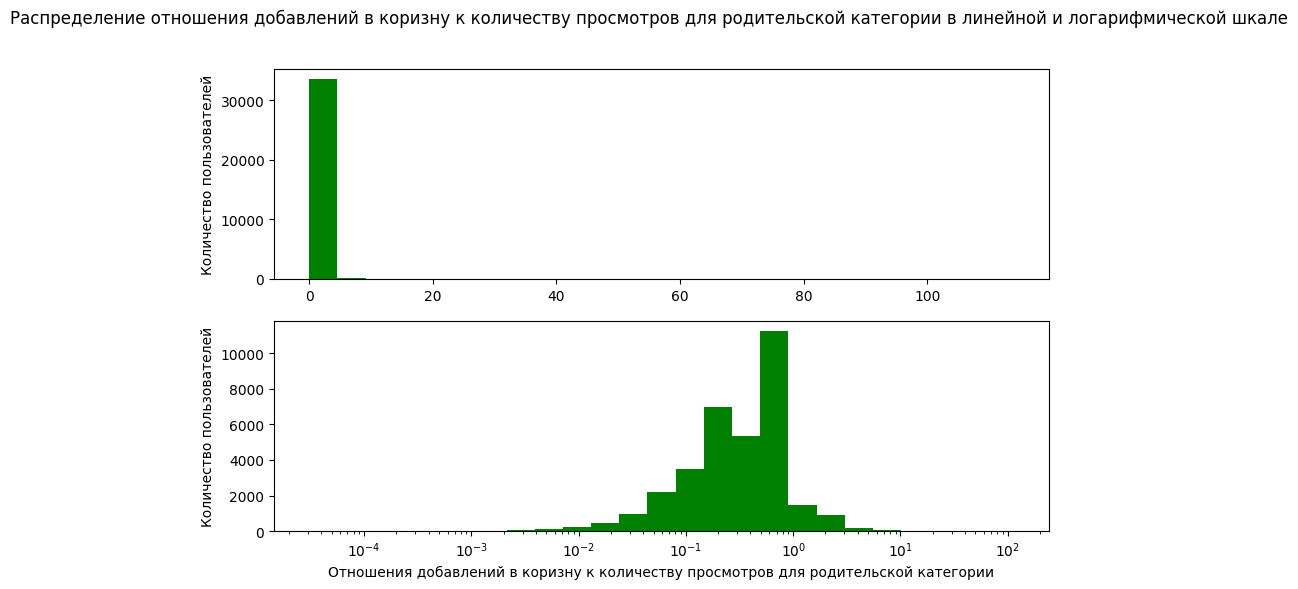

In [61]:
plt.figure(figsize=(10, 6))
plt.suptitle('Распределение отношения добавлений в коризну к количеству просмотров для родительской категории в линейной и логарифмической шкале')
plt.subplot(211)
data_for_hist = user_events.loc[~(user_events['ratio_addtocart'] == np.inf) & 
                                (user_events['ratio_addtocart'] != 0), 'ratio_addtocart']
hist, bins, _ = plt.hist(data_for_hist, bins=25, color='g')
plt.ylabel('Количество пользователей')

logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
plt.subplot(212)
plt.hist(data_for_hist, bins=logbins, color='g')
plt.xscale('log')
plt.xlabel('Отношения добавлений в коризну к количеству просмотров для родительской категории')
plt.ylabel('Количество пользователей')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'ratio_addtocart_parent_cat'))

Здесь распределение сместилось также ближе к единице, что объяснимо, поскольку чаще люди смотрят определённую категорию товаров, а затем что-то выбирают и добавлют в корзину.

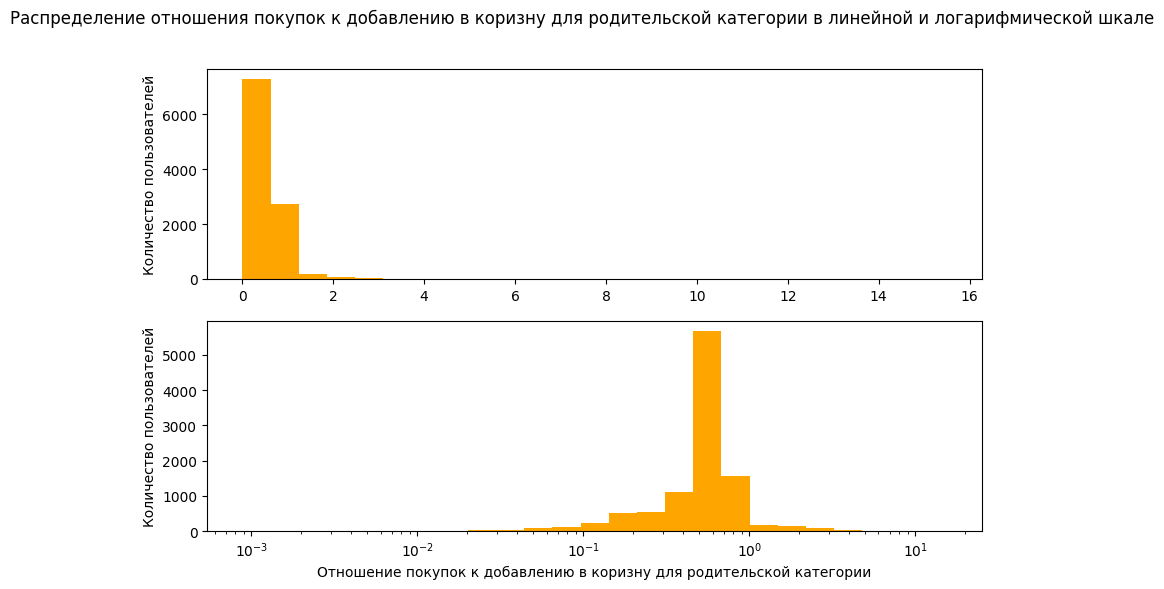

In [62]:
plt.figure(figsize=(10, 6))
plt.suptitle('Распределение отношения покупок к добавлению в коризну для родительской категории в линейной и логарифмической шкале')
plt.subplot(211)
data_for_hist = user_events.loc[~(user_events['ratio_transaction'] == np.inf) & 
                                (user_events['ratio_transaction'] != 0), 'ratio_transaction']
hist, bins, _ = plt.hist(data_for_hist, bins=25, color='orange')
plt.ylabel('Количество пользователей')

logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
plt.subplot(212)
plt.hist(data_for_hist, bins=logbins, color='orange')
plt.xscale('log')
plt.xlabel('Отношение покупок к добавлению в коризну для родительской категории')
plt.ylabel('Количество пользователей')

plt.savefig(os.path.join(GRAPHS_FOLDER, 'ratio_transaction_parent_cat'))

Здесь, при укрупнении до родительской категории так же наблюдается смещение распределния к единице, что так же можно объяснить тем, что пользователи часто  могут добавлять товары в корзину из одной родительской категории и потом выбрать один товар. 

In [63]:
del user_events

### Выводы

На основе анализа динамики действий пользователя было установлено, что:
- просмотры, добавления в корзиу и продажы имеют некую сезонность (пики примерно два дня в неделю);
- то, что человек просмотрит товар не значит, что он его купит (просмотров на порядки больше);
- добавление товара в корзину не означает покупку товара, хотя разрыв не такой большой как между просмотрами и добавлением в корзину;
- после 2015-09-15 наблюдается сильное падение количества взаимодействий (причина неизвестна, и эти данные необходимо удалить).

Также были обнаружены следующие аномалии:
- бывают добавления в корзину без просмотров (это либо ошибка, либо сервис позволяет такие действия);
- в выборке есть выбросы по всем трём категориям (есть пользователи, которые совершают очень много покупок, просматривают очень больщое количество товаров и т.д.). И либо это уникальные пользователи, либо боты, но в любом случае их лучше не рассматривать вместе со всеми и отбросить как выбросы, чтобы модель корректно отрабатывала на большинстве пользователей;
- у товаров очень много признаков с долей пропусков свыше 0.9, поэжтому было принято решение оставить только те у которых пропусков меньше 0.1;
- все признаки помимо двух закодированы цифрами и не ясно, что они обозначают, поэтому также были отброшены признаки с большой долей уникальных значений (поскольку не понятно, как их в дальнейшем сравнивать);
- у некоторых товаров нет родительской категории.

В ходе анализа отношения количества добавлений товара в корзину к количеству просмотров было установлено что:
- в среднем человек просматривает товар 2-3 раза перед добавлением в корзину, также данное распределение имеет достаточно массивную левую часть;
- при укрупнении до категорий, а затем и до родительских категорий происходит смещение к единице и утяжедение левого хвоста, что говорит о том, что пользователи часто просматривают схожие товары, чтобы затем выбрать нужный товар.

В ходе анализа отношения количества покупок к добавлению в корзину было установлено:
- распределение смещено правее, относительно предыдущего, и в целом имеет более массивную правую часть, что говорит о том, что большинство пользователей при добавлении товара в корзину, как равило совершают покупку данного товара; 
- также при укрпнени товаров до категорий и родительской категории наблюдается смещение к единице, т.е. действительно есть пользователи, которые добавляют схожие товары в корзину, а затем выбирают и покупают один.

Залогируем полученные результаты в Mlflow

In [58]:
experiment= mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

RUN_NAME = "eda"

In [59]:
with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    mlflow.log_artifacts(GRAPHS_FOLDER)

🏃 View run eda at: http://127.0.0.1:5000/#/experiments/16/runs/91b8eaf6bea14467aee6a193472bb8ed
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/16


## Preprocessing

Уберём из таблицы событий свойства, айтемов.

In [67]:
events = events.drop(['6', '678', '839', 'categoryid', 'parentid'], axis=1)

Также мы хотели почистить нашу выборку от выбросов по количеству средних совершённых действий в день, поэтому снова получим информацию по пользователям.

In [68]:
user_events = pd.pivot_table(events, 
                            index=['visitorid', 'date'], 
                            columns=['event'], 
                            values='itemid', 
                            aggfunc='count').reset_index(drop=False)

user_events = user_events.groupby('visitorid').agg(
    view=('view', 'mean'),
    addtocart=('addtocart', 'mean'),
    transaction=('transaction', 'mean')
)

user_events = user_events.fillna(0)

user_events.shape

(1395013, 3)

Исходя из графиков за выбросы будем принимать значения свыше 10 для просмотров и свыше 5 для добавления в корзину и покупок

In [69]:
user_events = user_events.loc [(user_events['view'] <= 10) &
                                (user_events['addtocart'] <= 5) &
                                (user_events['transaction'] <= 5)]

user_list = user_events.index.to_list()

user_events.shape

(1388688, 3)

Мы потеряли не так много пользователей, зато избавились от выбросов. Оставим в датасете с событиями только корректных пользователей.

In [70]:
events = events.loc[events['visitorid'].isin(user_list)]

Снова вычитаем информацию о товарах, чтобы получить историю доступности товара (сохраним её как отдельный файл).

In [71]:
items_history = pd.concat([pd.read_csv(f'{DATA_FOLDER}/item_properties_part1.csv'),
                            pd.read_csv(f'{DATA_FOLDER}/item_properties_part2.csv')
                            ], axis=0).sort_values(by=['itemid', 'property', 'timestamp']).reset_index(drop=True)

In [72]:
items_history = items_history[items_history['property'] == 'available']
items_history = items_history.drop('property', axis=1)
items_history = items_history.rename(columns={'value': 'available'})
items_history['date'] = items_history['timestamp'].progress_apply(lambda x: datetime.fromtimestamp(x/1000).date())
items_history.head()

100%|██████████| 1503639/1503639 [00:01<00:00, 1030729.95it/s]


,timestamp,itemid,available,date
43,1431831600000,0,0,2015-05-17
112,1431226800000,1,1,2015-05-10
113,1431831600000,1,0,2015-05-17
114,1432436400000,1,0,2015-05-24
115,1433041200000,1,0,2015-05-31


Переименуем названия колонок в наших датасетах в ощепринятые.

In [73]:
events = events.rename(columns={'visitorid': 'user_id',
                       'itemid': 'item_id'})
items_history = items_history.rename(columns={'itemid': 'item_id'})
items = items.rename(columns={'itemid': 'item_id'})

Сохраним получившиеся датасеты, чтобы в дальнейшем с ними работать.

In [74]:
events.to_csv(f'{DATA_FOLDER}/preprocessed/events.csv', index=False)
items.to_csv(f'{DATA_FOLDER}/preprocessed/items.csv', index=False)
items_history.to_csv(f'{DATA_FOLDER}/preprocessed/items_history.csv', index=False)

Загрузим данные в S3

In [75]:
s3 = get_session()

s3.upload_file(f'{DATA_FOLDER}/preprocessed/events.csv', S3_BUCKET_NAME, 'recsys_ec/data/events.parquet')
s3.upload_file(f'{DATA_FOLDER}/preprocessed/items.csv', S3_BUCKET_NAME, 'recsys_ec/data/items.parquet')
s3.upload_file(f'{DATA_FOLDER}/preprocessed/items_history.csv', S3_BUCKET_NAME, 'recsys_ec/data/items_history.parquet')

Очистим память.

In [76]:
del events, items, items_history, user_events, user_list

## Modeling

Можно начать выполнение ноутбука с этого пункта, но предварительно необходимо выполнить ячейки перед EDA. Выгрузим данные из S3

In [7]:
s3 = get_session()

s3.download_file(S3_BUCKET_NAME, 'recsys_ec/data/events.parquet', f'{DATA_FOLDER}/preprocessed/events.csv')
s3.download_file(S3_BUCKET_NAME, 'recsys_ec/data/items.parquet', f'{DATA_FOLDER}/preprocessed/items.csv')
s3.download_file(S3_BUCKET_NAME, 'recsys_ec/data/items_history.parquet', f'{DATA_FOLDER}/preprocessed/items_history.csv')

In [77]:
items = pd.read_csv(f'{DATA_FOLDER}/preprocessed/items.csv')
events = pd.read_csv(f'{DATA_FOLDER}/preprocessed/events.csv')

Оставим только информацию по событиям добавления в корзину

In [78]:
events = events[events['event'] == 'addtocart'].reset_index()

Также удалим события с товарами по которым нет информации

In [79]:
events = events[events['item_id'].isin(items['item_id'].values.tolist())]

Разделим данные на тренировочную, тестовую выборку 1 и тестовую выборку2 (тестовая выборка 1 потребуется в дальнейшем, когда будем обучать модель для отбора лучших рекомендаций)

В каждую из тестовых выборок определим по 2 недели, соответственно отделим данные по 2015-09-01 и 2015-08-14

In [35]:
train_test_global_time_split_date = pd.to_datetime("2015-09-01").to_datetime64()
train_test_global_time_split_idx = pd.to_datetime(events["date"]) < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx].reset_index(drop=True)
events_test_2 = events[~train_test_global_time_split_idx].reset_index(drop=True)

In [36]:
train_test_global_time_split_date = pd.to_datetime("2015-08-14").to_datetime64()
train_test_global_time_split_idx = pd.to_datetime(events_train["date"]) < train_test_global_time_split_date
events_test_1 = events_train[~train_test_global_time_split_idx].reset_index(drop=True)
events_train = events_train[train_test_global_time_split_idx].reset_index(drop=True)

Выведем размеры получившихся датасетов.

In [37]:
events_train.shape, events_test_1.shape, events_test_2.shape

((37311, 15), (6141, 15), (5099, 15))

Так как у нас id идут не по порядку, то при помощи LabelEncoder преобразуем их в порядковые.

In [38]:
user_encoder = LabelEncoder()
user_encoder.fit(events["user_id"])
events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
events_test_1["user_id_enc"] = user_encoder.transform(events_test_1["user_id"])
events_test_2["user_id_enc"] = user_encoder.transform(events_test_2["user_id"])

In [39]:
item_encoder = LabelEncoder()
item_encoder.fit(items["item_id"])
items["item_id_enc"] = item_encoder.transform(items["item_id"])
events_train["item_id_enc"] = item_encoder.transform(events_train["item_id"])
events_test_1["item_id_enc"] = item_encoder.transform(events_test_1["item_id"])
events_test_2["item_id_enc"] = item_encoder.transform(events_test_2["item_id"])

Поскольку качество будем проверять на 2 тестовом датасете, то сразу посмотрим сколько у нас уникальных пользователей в тренировочном, тестовом датасете, сколько из них встречаются в обоих датасетах.

In [40]:
# количество пользователей в train и test
users_train = events_train["user_id"].drop_duplicates()
users_test = events_test_2["user_id"].drop_duplicates()
# количество пользователей, которые есть и в train, и в test
common_users = list(set(users_train) & set(users_test))

print(len(users_train), len(users_test), len(common_users)) 

26821 3733 94


Выведем количество "холодных" пользователей.

In [41]:
cold_users = list(set(users_test) - set(common_users))

print(len(cold_users))

3639


Как видим у нас очень много холодны пользователей, это связано с тем, что записей о действиях пользователей примерно в 2 раза больше чем самих уникальных пользователей, учитывая, что помимо добавления в корзину есть ещё действия просмотра, то логично, что большинство пользователей встречаются примерно 2 раза во всё датасете.

### Метрики

Сразу определимся с метриками, чтобы можно было оценивать какого эффекта мы добились в качестве метрик воспользуемся бинарными: точностью и полнотой, и специфичными: покрытием и новизной. Создадим несколько функций, чтобы сразу получать все метрики.

In [18]:
def process_events_recs_for_binary_metrics(events_train, events_test, recs, top_k=None, items_from_train=True):

    """
    размечает пары <user_id, item_id> для общего множества пользователей признаками
    - gt (ground truth)
    - pr (prediction)
    top_k: расчёт ведётся только для top k-рекомендаций
    """

    events_test["gt"] = True
    common_users = set(events_test["user_id"]) & set(recs["user_id"])
    
    events_for_common_users = events_test[events_test["user_id"].isin(common_users)].copy()
    recs_for_common_users = recs[recs["user_id"].isin(common_users)].copy()

    recs_for_common_users = recs_for_common_users.sort_values(["user_id", "score"], ascending=[True, False])

    if items_from_train:
        # оставляет только те item_id, которые были в events_train, 
        # т. к. модель не имела никакой возможности давать рекомендации для новых айтемов
        events_for_common_users = events_for_common_users[events_for_common_users["item_id"].isin(events_train["item_id"].unique())]

    if top_k is not None:
        recs_for_common_users = recs_for_common_users.groupby("user_id").head(top_k)
    
    events_recs_common = events_for_common_users[["user_id", "item_id", "gt"]].merge(
        recs_for_common_users[["user_id", "item_id", "score"]], 
        on=["user_id", "item_id"], how="outer")    

    events_recs_common["gt"] = events_recs_common["gt"].fillna(False)
    events_recs_common["pr"] = ~events_recs_common["score"].isnull()
    
    events_recs_common["tp"] = events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fp"] = ~events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fn"] = events_recs_common["gt"] & ~events_recs_common["pr"]

    return events_recs_common 

In [19]:
def compute_cls_metrics(events_recs_for_binary_metrics):
    
    groupper = events_recs_for_binary_metrics.groupby("user_id")

    # precision = tp / (tp + fp)
    precision = groupper["tp"].sum()/(groupper["tp"].sum()+groupper["fp"].sum())
    precision = precision.fillna(0).mean()
    
    # recall = tp / (tp + fn)
    recall = groupper["tp"].sum()/(groupper["tp"].sum()+groupper["fn"].sum())
    recall = recall.fillna(0).mean()

    return precision, recall 

In [20]:
def get_bin_metrics(events_train, events_test, recs, top_k=None):
    events_recs_for_binary_metrics = process_events_recs_for_binary_metrics(events_train,
                                                                            events_test, 
                                                                            recs, 
                                                                            top_k)
    precision, recall  = compute_cls_metrics(events_recs_for_binary_metrics)
    return precision, recall

In [21]:
def get_specific_metrics(recs, events_train, events_test, top_k=None):
    recs = recs.copy(deep=True)
    if top_k is not None:
        recs = recs.groupby("user_id").head(top_k)

    # расчитаем покрытие товаров
    cov_items = len(recs['item_id'].unique()) / len(events_train['item_id'].unique())

    # расчитаем покрытие пользователей в тестовом датасете    
    cov_user = len(recs.loc[recs['user_id'].isin(events_test['user_id'].tolist()), 'user_id'].unique()) / len(events_test['user_id'].unique())

    # разметим каждую рекомендацию признаком added 
    events_train["added"] = True
    recs = recs.merge(events_train, on=["user_id", "item_id"], how="left")
    recs["added"] = recs["added"].fillna(False).astype("bool")

    # проставим ранги
    recs = recs.sort_values('score', ascending=False)
    recs["rank"] = recs.groupby("user_id").cumcount() + 1

    # посчитаем novelty по пользователям
    novelty = (1 - recs.groupby("user_id")["added"].mean())

    # посчитаем средний novelty
    novelty = novelty.mean()
    return cov_items, cov_user, novelty

In [22]:
def get_metrics(events_train, events_test, recs, top_k=None):
    precision, recall = get_bin_metrics(events_train, events_test, recs, top_k)
    cov_items, cov_user, novelty = get_specific_metrics(recs, events_train, events_test, top_k)
    metrics = {}
    metrics[f'precision_{top_k}'] = precision
    metrics[f'recall_{top_k}'] = recall
    metrics[f'cov_items_{top_k}'] = cov_items
    metrics[f'cov_user_test_{top_k}'] = cov_user
    metrics[f'novelty_{top_k}'] = novelty
    return metrics

### Топ популярных

Найдём самые популярные товары для добавления в корзину в трейновом датасете.

In [23]:
events_train_pop = events_train[events_train['event'] == 'addtocart'].reset_index()
item_popularity = events_train_pop.groupby(["item_id"]).agg(count_users=("user_id", "nunique")).reset_index()

item_popularity = item_popularity.sort_values('count_users', ascending=False).reset_index(drop=True)
top_k_pop_items  = item_popularity.head(100)

In [87]:
top_k_pop_items.head()

,item_id,count_users
0,461686,147
1,312728,98
2,409804,93
3,29196,84
4,48030,72


Присоединим наши рекомендации к "холодным" пользователям и оставим тех для кого подошёл наш прогноз.

In [88]:
cold_users_events_with_recs = \
    events_test_2[events_test_2["user_id"].isin(cold_users)] \
    .merge(top_k_pop_items, on="item_id", how="left")

cold_user_items_no_avg_rating_idx = cold_users_events_with_recs["count_users"].isnull()
cold_user_recs = cold_users_events_with_recs[~cold_user_items_no_avg_rating_idx]

Посмотрим какую долю событий мы предсказали

In [89]:
cold_user_recs.shape[0] / cold_users_events_with_recs.shape[0]

0.058355437665782495

Холодный прогноз подошёл для 5,64 процентов пользователей.

Посмотрим на метрики, для этого создадим датасет где для каждого пользователя будут одни и те же рекомендации (в качестве скора будет отношение пользователей, выбравший данный товар к максимальному количеству пользователей выбравших один и тот же товар.).

In [90]:
users = []
recs = []
scores = []
for user in events['user_id'].unique():
    users.extend([user] * len(top_k_pop_items))
    recs.extend(top_k_pop_items['item_id'].values.tolist())
    scores.extend((top_k_pop_items['count_users'] / top_k_pop_items['count_users'].max()).values.tolist())

df_top_recs = pd.DataFrame({'user_id': users,
                            'item_id': recs,
                            'score': scores})    

Здесь и далее будем проверять только топ 10 рекомендаций (это более близко к реальным условиям)

In [91]:
metrics = get_metrics(events_train, events_test_2, df_top_recs, 10)
metrics

C:\Users\yaros\AppData\Local\Temp\ipykernel_10424\2210385462.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  events_recs_common["gt"] = events_recs_common["gt"].fillna(False)
C:\Users\yaros\AppData\Local\Temp\ipykernel_10424\1583317232.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  recs["added"] = recs["added"].fillna(False).astype("bool")


{'precision_10': 0.0013747168984243722,
 'recall_10': 0.01007456022859184,
 'cov_items_10': 0.0006334325711028061,
 'cov_user_test_10': 1.0,
 'novelty_10': 0.9975284422042521}

Ожидаемо, что точность и покрытие имеют низкое значение (поскольку мы рекомендуем только 10 товаров из всего перечня и рекомендуем их всем, а пользователи в среднем добавляют 1-2 товара в корзину). По этой же причине  новизна очень высокая, т.к. средний пользователь добавлял только 1-2 товара, а мы предложили ему целых 10 новых

Залогируем наши метрики

In [92]:
experiment= mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

RUN_NAME = "top_popular"

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    mlflow.log_metrics(metrics)

🏃 View run top_popular at: http://127.0.0.1:5000/#/experiments/16/runs/19ee9956ff734bbea24b34d7db911d4e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/16


Сохраним полученные рекомендации.

In [93]:
df_top_recs.to_parquet(f'{RECOMENDATION_FOLDER}/top_popular.parquet')

Загрузим в S3

In [9]:
s3 = get_session()

s3.upload_file(f'{RECOMENDATION_FOLDER}/top_popular.parquet', S3_BUCKET_NAME, 'recsys_ec/recommendations/top_popular.parquet')

### Персональные

Создадим разреженную матрицу добавлений товара в корзину конкретным пользователем. В качестве значений будем использовать просто единицы.

In [95]:
user_item_matrix_train = scipy.sparse.csr_matrix((
    [1] * events_train.shape[0],
    (events_train['user_id_enc'], events_train['item_id_enc'])),
    dtype=np.int8) 

Обучим ALS модель.

In [96]:
als_model = AlternatingLeastSquares(factors=150, iterations=10, regularization=0.05, random_state=0)
als_model.fit(user_item_matrix_train) 

w:\education\mle\mle-pr-final\.venv\lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 10/10 [00:01<00:00,  6.64it/s]


Получаем топ 100 рекомендаций для всех пользователей

In [97]:
# получаем список всех возможных user_id (перекодированных)
user_ids_encoded = range(len(user_encoder.classes_))

# получаем рекомендации для всех пользователей
als_recommendations = als_model.recommend(
    user_ids_encoded, 
    user_item_matrix_train[user_ids_encoded], 
    filter_already_liked_items=False, N=100) 

Преобразуем полученные рекомендации к табличному формату и сразу декадируем id

In [98]:
# получаем рекомендации и скоры
item_ids_enc = als_recommendations[0]
als_scores = als_recommendations[1]

# преобразуем в датафрейм
als_recommendations = pd.DataFrame({
    "user_id_enc": user_ids_encoded,
    "item_id_enc": item_ids_enc.tolist(), 
    "score": als_scores.tolist()})
als_recommendations = als_recommendations.explode(["item_id_enc", "score"], ignore_index=True)

# приводим типы данных
als_recommendations["item_id_enc"] = als_recommendations["item_id_enc"].astype("int")
als_recommendations["score"] = als_recommendations["score"].astype("float")

# получаем изначальные идентификаторы
als_recommendations["user_id"] = user_encoder.inverse_transform(als_recommendations["user_id_enc"])
als_recommendations["item_id"] = item_encoder.inverse_transform(als_recommendations["item_id_enc"])
als_recommendations = als_recommendations.drop(columns=["user_id_enc", "item_id_enc"]) 

In [99]:
als_recommendations['user_id'].nunique()

34857

Посмотрим на качество рекомендаций

In [100]:
metrics = get_metrics(events_train, events_test_2, als_recommendations, 10)
metrics

C:\Users\yaros\AppData\Local\Temp\ipykernel_10424\2210385462.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  events_recs_common["gt"] = events_recs_common["gt"].fillna(False)
C:\Users\yaros\AppData\Local\Temp\ipykernel_10424\1583317232.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  recs["added"] = recs["added"].fillna(False).astype("bool")


{'precision_10': 0.0002678810608090008,
 'recall_10': 0.0015358514153049378,
 'cov_items_10': 0.08386647241401153,
 'cov_user_test_10': 1.0,
 'novelty_10': 0.9740092951541346}

У нас значительно выросла полнота и покрытие, однако точность и полнота подсели.

Залогируем метрики в MLflow

In [101]:
experiment= mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

RUN_NAME = "personal_als"

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    mlflow.log_metrics(metrics)

🏃 View run personal_als at: http://127.0.0.1:5000/#/experiments/16/runs/3560a97995c849a3a17f05670ae4ec38
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/16


Сохраним получившийся датасет и загрузим его в S3

In [10]:
als_recommendations = als_recommendations[["user_id", "item_id", "score"]]
als_recommendations.to_parquet(f'{RECOMENDATION_FOLDER}/personal_als.parquet') 

s3 = get_session()
s3.upload_file(f'{RECOMENDATION_FOLDER}/personal_als.parquet', S3_BUCKET_NAME, 'recsys_ec/recommendations/personal_als.parquet')

### Похожие

Найдём похожие айтемы

In [103]:
# получим энкодированные идентификаторы всех объектов, известных нам из events_train
train_item_ids_enc = events_train['item_id_enc'].unique()

max_similar_items = 100

# получаем списки похожих объектов, используя ранее полученную ALS-модель
# метод similar_items возвращает и сам объект, как наиболее похожий
# этот объект мы позже отфильтруем, но сейчас запросим на 1 больше

similar_items = als_model.similar_items(train_item_ids_enc, N=max_similar_items+1)

# преобразуем полученные списки в табличный формат
sim_item_item_ids_enc = similar_items[0]
sim_item_scores = similar_items[1]

similar_items = pd.DataFrame({
    "item_id_enc": np.array([[ind for _ in range(max_similar_items + 1)] for ind in train_item_ids_enc]).flatten(),
    "sim_item_id_enc": np.array(sim_item_item_ids_enc.tolist()).flatten(), 
    "score": np.array(sim_item_scores.tolist()).flatten()})

# приводим типы данных
similar_items["sim_item_id_enc"] = similar_items["sim_item_id_enc"].astype("int")
similar_items["score"] = similar_items["score"].astype("float")

# получаем изначальные идентификаторы
item_decod = {row[0]: row[1] for row in zip(events_train['item_id_enc'].tolist(), events_train['item_id'].tolist())}
similar_items["item_id_1"] = similar_items['item_id_enc'].map(item_decod)
similar_items["item_id_2"] = similar_items['sim_item_id_enc'].map(item_decod)
similar_items = similar_items.drop(columns=["item_id_enc", "sim_item_id_enc"])

# убираем пары с одинаковыми объектами
similar_items = similar_items.query("item_id_1 != item_id_2") 

Посмотрим, что получилось.

In [104]:
similar_items.head()

,score,item_id_1,item_id_2
1,0.627597,452955,31678
2,0.614689,452955,269016
3,0.614689,452955,100438
4,0.605932,452955,67615
5,0.567474,452955,223075


Сохраним получившиеся результаты

In [11]:
similar_items.to_parquet(f'{RECOMENDATION_FOLDER}/similar.parquet') 

s3 = get_session()
s3.upload_file(f'{RECOMENDATION_FOLDER}/similar.parquet', S3_BUCKET_NAME, 'recsys_ec/recommendations/similar.parquet')

### Ранжинующая модель

#### Построение признаков.

У нас будет две группы признаков 
- первая связаная с действиями пользователей (покупка, просмотр или добавление в корзину таких товаров, либо из такой категории (заготовка для данных признаков уже есть в таблице events нужно будет только отсечь последние известные действия по парам пользователь / товар, чтобы не получить утечки данных))
- вторая будет связанная с косинусным растоянием между товаром (свойствами) и средним вектором действий пользователя.

Начнём со второй задачи и сделаем функцию, которая будет для товаров получать разреженную матрицу по их свойствам.

In [43]:
def get_item2porp_matrix(items: pd.DataFrame, column_prop: str) -> scipy.sparse.csr_matrix:

    prop_names_to_id = {k: v for v, k in enumerate(items[column_prop].unique())}
    
    # list to build CSR matrix
    csr_data = []
    csr_row_idx = []
    csr_col_idx = []
    
    for item_idx, (k, v) in tqdm(enumerate(items.iterrows())):
        if np.isnan(v['parentid']):
            continue
        prop_idx = prop_names_to_id[v[column_prop]]
        csr_data.append(int(1))
        csr_row_idx.append(item_idx)
        csr_col_idx.append(prop_idx)

    prop_csr = scipy.sparse.csr_matrix((csr_data, (csr_row_idx, csr_col_idx)), shape=(len(items), len(items[column_prop].unique())))
    
    return prop_csr 

Поскольку у нас несколько столбцов с признаками, то напишем функцию, которая будет поочередно обрабатывать все признаки.

In [44]:
def get_all_prop_matrix(items: pd.DataFrame, list_columns: list[str]) -> scipy.sparse.csr_matrix:
    res = None
    for col in list_columns:
        if res is None:
            res = get_item2porp_matrix(items, col)
        else:
            res = scipy.sparse.hstack((res, get_item2porp_matrix(items, col)))
    return res

In [45]:
items = items.sort_values(by="item_id_enc")
all_items_prop_csr = get_all_prop_matrix(items, ['6', '678', '839', 'categoryid', 'parentid'])


417053it [00:18, 22456.18it/s]
417053it [00:18, 22475.32it/s]
417053it [00:18, 22542.25it/s]
417053it [00:18, 22619.94it/s]
417053it [00:18, 22432.44it/s]


Напишум функцию, которая будет возвращать растояние до товаров от среднего вектора пользователя (по покупкам, добавлениям в корзину и просмотрам)

In [46]:
def get_content_rec(df: pd.DataFrame, 
                    type_events: str,
                    df_user_als_item_list: pd.DataFrame,
                    df_top_item: pd.DataFrame,
                    all_items_prop_csr: scipy.sparse._csr.csr_matrix, 
                    item_encoder: LabelEncoder) -> pd.DataFrame:
    
    df = df.loc[df['event'] == type_events].reset_index(drop=True)
    # получаем все уникальные айтемы для конкретного пользователя
    df_user_item_list = df[['user_id', 'item_id_enc']].groupby('user_id').agg({'item_id_enc': 'unique'})

    user_ids = df['user_id'].unique()
    user_id_list = []
    item_id_enc_list = []
    score_list = []
    
    for user_id in tqdm(user_ids):
        # Получаем лист рекомендованных эйтемов (если есть персональные, то добавляем их, плюс всем топ популяреных)
        list_id_rec = df_top_item['item_id_enc'].tolist()
        if user_id in df_user_als_item_list['user_id'].to_list():
            list_id_rec.extend(df_user_als_item_list.loc[df_user_als_item_list['user_id'] == user_id, 'item_id_enc'].tolist())

        list_id_rec = list(set(list_id_rec))
        k = len(list_id_rec)
        # для каждого пользователя получаем средний вектор товаров
        user_prop = all_items_prop_csr[df_user_item_list.loc[user_id, 'item_id_enc']].mean(axis=0).tolist()[0]        
        user_prop = np.array(user_prop).reshape(1, -1)    
        # вычисляем сходство между вектором пользователя и всеми товарами
        similarity_scores = cosine_similarity(all_items_prop_csr[list_id_rec], user_prop)
        # преобразуем в одномерный массив
        similarity_scores = similarity_scores.flatten()
        
        user_id_list.extend([user_id] * k)
        item_id_enc_list.extend(list_id_rec)
        score_list.extend(similarity_scores.tolist())
    df_rec = pd.DataFrame({
        'user_id': np.array(user_id_list),
        'item_id': item_encoder.inverse_transform(item_id_enc_list),
        'score': np.array(score_list)
    })

    return df_rec

Вычитаем весь датасет со вcеми действиями, выделим только тренировочную часть и добавим столбец с кодированными id для товаров.

In [47]:
events_all = pd.read_csv(f'{DATA_FOLDER}/preprocessed/events.csv')
events_all = events_all[events_all['user_id'].isin(events['user_id'].unique().tolist())]

train_test_global_time_split_date = pd.to_datetime("2015-08-14").to_datetime64()
train_test_global_time_split_idx = pd.to_datetime(events_all["date"]) < train_test_global_time_split_date
events_train_all = events_all[train_test_global_time_split_idx].reset_index(drop=True)

events_train_all = events_train_all.loc[events_train_all['item_id'].isin(items['item_id'].tolist())]
events_train_all["item_id_enc"] = item_encoder.transform(events_train_all["item_id"])

In [48]:
als_recommendations['item_id_enc'] = item_encoder.transform(als_recommendations['item_id'])
df_top_recs['item_id_enc'] = item_encoder.transform(df_top_recs['item_id'])

In [49]:
df_addtocart = get_content_rec(events_train_all, 'addtocart', als_recommendations, df_top_recs, all_items_prop_csr, item_encoder)
df_view = get_content_rec(events_train_all, 'view', als_recommendations, df_top_recs, all_items_prop_csr, item_encoder)
df_transaction = get_content_rec(events_train_all, 'transaction', als_recommendations, df_top_recs, all_items_prop_csr, item_encoder)

100%|██████████| 7423/7423 [17:41<00:00,  6.99it/s]


Переименуем столбцы и объединим их в один датасет.

In [52]:
df_addtocart = df_addtocart.rename(columns={'score': 'cosin_sim_addtocart'})
df_view = df_view.rename(columns={'score': 'cosin_sim_view'})
df_transaction = df_transaction.rename(columns={'score': 'cosin_sim_transaction'})

In [56]:
df_cosin_sim = df_addtocart.merge(df_view, on = ['user_id', 'item_id'], how='outer')
df_cosin_sim = df_cosin_sim.merge(df_transaction, on = ['user_id', 'item_id'], how='outer')

Заполним пропуски нулями.

In [ ]:
df_cosin_sim.fillna(0)

user_id                        0
item_id                        0
cosin_sim_addtocart       114600
cosin_sim_view            432794
cosin_sim_transaction    3690558
dtype: int64

Сохраним полученный датасет и удалим ненужные.

In [73]:
df_cosin_sim.to_parquet(f'{DATA_FOLDER}/cos_similarity.parquet') 

In [63]:
del df_addtocart, df_view, df_transaction

Теперь получим признаки по истории действий пользователя. Нам заново нужно будет открыть все действия пользователей и оставить полсднее взаимодействие в паре пользователь / товар.

In [65]:
events_all = pd.read_csv(f'{DATA_FOLDER}/preprocessed/events.csv')

train_test_global_time_split_date = pd.to_datetime("2015-08-14").to_datetime64()
train_test_global_time_split_idx = pd.to_datetime(events_all["date"]) < train_test_global_time_split_date
events_train_all = events_all[train_test_global_time_split_idx].reset_index(drop=True)

events_train_all = events_train_all.loc[events_train_all['item_id'].isin(items['item_id'].tolist())]

events_all = events_train_all.sort_values(['user_id', 'item_id', 'timestamp'])
events_last = events_train_all.drop_duplicates(subset=['user_id', 'item_id'], keep='last')

Сохраним полученный датасет. И удалим ненужные

In [66]:
events_last.to_parquet(f'{DATA_FOLDER}/events_last.parquet') 

In [67]:
del events_all

#### Получение финального датасета с признаками

Повторно вычитаем датасеты и объединим их

In [24]:
als_recommendations = pd.read_parquet(f'{RECOMENDATION_FOLDER}/personal_als.parquet')
df_top_recs = pd.read_parquet(f'{RECOMENDATION_FOLDER}/top_popular.parquet')

candidates = pd.merge(
    als_recommendations[["user_id", "item_id", "score"]].rename(columns={"score": "als_score"}),
    df_top_recs[["user_id", "item_id", "score"]].rename(columns={"score": "top_score"}),
    on=["user_id", "item_id"],
    how="outer") 
del als_recommendations, df_top_recs

In [25]:
events_last = pd.read_parquet(f'{DATA_FOLDER}/events_last.parquet') 
events_last = events_last.drop(['timestamp', 'event', 'date'], axis=1)

candidates = candidates.merge(events_last, 
    on=["user_id", "item_id"],
    how="outer") 
del events_last

In [26]:
df_cosin_sim = pd.read_parquet(f'{DATA_FOLDER}/cos_similarity.parquet') 

candidates = candidates.merge(df_cosin_sim, 
    on=["user_id", "item_id"],
    how="outer") 
del df_cosin_sim

Поскольку у нас товар для конкретного пользователя может не оказаться ни в рекомендации ALS, ни в ТОП предложениях (а значит и косинусное растояние по ним не рассчитано), то сделаем отдельный столбец, в котором отметим такие пары товар / пользователь прежде чем заполянть пропуски нулями.

In [27]:
candidates['not_rec'] = 0
candidates.loc[candidates[['als_score', 'top_score']].isna().any(axis=1), 'not_rec'] = 1

In [28]:
candidates = candidates.fillna(0)

Сохраняем результат

In [29]:
candidates.to_parquet(f'{DATA_FOLDER}/candidates.parquet', index=False)

На основе events_test_1 разметим получившийся датасет. 

In [ ]:
events_test_1["target"] = 1
candidates = candidates.merge(events_test_1[["user_id", "item_id", "target"]], 
                              on=["user_id", "item_id"],
                              how='left')
candidates["target"] = candidates["target"].fillna(0).astype("int")

In [51]:
# в кандидатах оставляем только тех пользователей, у которых есть хотя бы один положительный таргет
candidates_to_sample = candidates.groupby("user_id").filter(lambda x: x["target"].sum() > 0)

# для каждого пользователя оставляем только 4 негативных примера
negatives_per_user = 4
candidates_for_train = pd.concat([
    candidates_to_sample.query("target == 1"),
    candidates_to_sample.query("target == 0") \
        .groupby("user_id") \
        .progress_apply(lambda x: x.sample(negatives_per_user, random_state=0))
    ]) 

100%|██████████| 487/487 [00:00<00:00, 2640.09it/s]


In [52]:
candidates_for_train.shape

(2524, 18)

### Обучение модели

In [53]:
# задаём имена колонок признаков и таргета
list_remove = ['user_id',  'item_id', 'target']
features = [c for c in candidates_for_train.columns.to_list() if c not in list_remove]
target = 'target'

# Создаём объект Pool
train_data = Pool(
    data=candidates_for_train[features], 
    label=candidates_for_train[target])

In [54]:
# инициализируем модель CatBoostClassifier
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    verbose=100,
    random_seed=0
)

# тренируем модель
cb_model.fit(train_data) 

0:	learn: 0.6208189	total: 135ms	remaining: 2m 15s
100:	learn: 0.1978894	total: 347ms	remaining: 3.09s
200:	learn: 0.1777451	total: 549ms	remaining: 2.18s
300:	learn: 0.1717966	total: 758ms	remaining: 1.76s
400:	learn: 0.1696980	total: 964ms	remaining: 1.44s
500:	learn: 0.1685624	total: 1.21s	remaining: 1.21s
600:	learn: 0.1679078	total: 1.42s	remaining: 943ms
700:	learn: 0.1674980	total: 1.62s	remaining: 691ms
800:	learn: 0.1672134	total: 1.82s	remaining: 453ms
900:	learn: 0.1670359	total: 2.03s	remaining: 223ms
999:	learn: 0.1668893	total: 2.22s	remaining: 0us


Выберем кандидатов для ранжирования, для экономии ресурсов оставляем только те, что есть в тестовой выборке.

In [55]:
# оставляем только тех пользователей, что есть в тестовой выборке, для экономии ресурсов
candidates_to_rank = candidates[candidates["user_id"].isin(events_test_2["user_id"].drop_duplicates())]
print(len(candidates_to_rank)) 

747890


Сделаем инференс на выбранных данных

In [56]:
inference_data = Pool(data=candidates_to_rank[features])
predictions = cb_model.predict_proba(inference_data)

candidates_to_rank["cb_score"] = predictions[:, 1]

# для каждого пользователя проставим rank, начиная с 1 — это максимальный cb_score
candidates_to_rank = candidates_to_rank.sort_values(["user_id", "cb_score"], ascending=[True, False])
candidates_to_rank["rank"] = candidates_to_rank.groupby("user_id").cumcount().add(1)

max_recommendations_per_user = 100
final_recommendations = candidates_to_rank.query("rank <= @max_recommendations_per_user") 

C:\Users\yaros\AppData\Local\Temp\ipykernel_1792\2743711160.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidates_to_rank["cb_score"] = predictions[:, 1]


In [57]:
final_recommendations = final_recommendations[['user_id', 'item_id', 'cb_score', 'rank']]
final_recommendations = final_recommendations.rename(columns={'cb_score': 'score'})
final_recommendations.head()

,user_id,item_id,score,rank
717,155,461686,0.998923,1
643,155,134620,0.997876,2
685,155,320130,0.997215,3
711,155,445351,0.996915,4
687,155,339703,0.988768,5


In [58]:
metrics = get_metrics(events_train, events_test_2, final_recommendations, 10)
metrics

C:\Users\yaros\AppData\Local\Temp\ipykernel_1792\2210385462.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  events_recs_common["gt"] = events_recs_common["gt"].fillna(False)
C:\Users\yaros\AppData\Local\Temp\ipykernel_1792\1583317232.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  recs["added"] = recs["added"].fillna(False).astype("bool")


{'precision_10': 0.002747841496836943,
 'recall_10': 0.020285293329761585,
 'cov_items_10': 0.031544942040919746,
 'cov_user_test_10': 1.0,
 'novelty_10': 0.9953403726374527}

В целом качество по точности и полноте стало немного лучше. Покрытие оказалось где-то посередине между топ рекомендациями и ALS. Залогируем данный результат.

In [59]:
experiment= mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id


pip_requirements  = "../requirements.txt"
signature = mlflow.models.infer_signature(candidates_to_rank, final_recommendations)
input_example = candidates_to_rank[:10]
RUN_NAME = "rank_model_all"

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    mlflow.log_metrics(metrics)

    mlflow.catboost.log_model(
        cb_model=cb_model,
        artifact_path='models',
        await_registration_for=60,
        registered_model_name=REGISTRY_MODEL_NAME,
        pip_requirements=pip_requirements,
        signature=signature,
        input_example=input_example
    )

w:\education\mle\mle-pr-final\.venv\lib\site-packages\mlflow\types\utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'recomendation_ec_model_yaroslav_knyazev' already exists. Creating a new version of this model...
2025/01/27 19:08:03 INFO mlflow.store.model_registry.abstract_store: Waiting up to 60 seconds for model version to fini

🏃 View run rank_model_all at: http://127.0.0.1:5000/#/experiments/16/runs/edc47977f5e54759ae488c1297ca4ed7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/16


Сохраним полные рекомендации.

In [12]:
final_recommendations.to_parquet(f'{RECOMENDATION_FOLDER}/recommendations.parquet') 

s3 = get_session()
s3.upload_file(f'{RECOMENDATION_FOLDER}/recommendations.parquet', S3_BUCKET_NAME, 'recsys_ec/recommendations/recommendations.parquet')

Посмотрим какие признаки были важны для модели.

In [61]:
df_weight = pd.DataFrame({'features': cb_model.feature_names_,
                          'feature_importances': cb_model.feature_importances_})
df_weight = df_weight.sort_values(by='feature_importances')

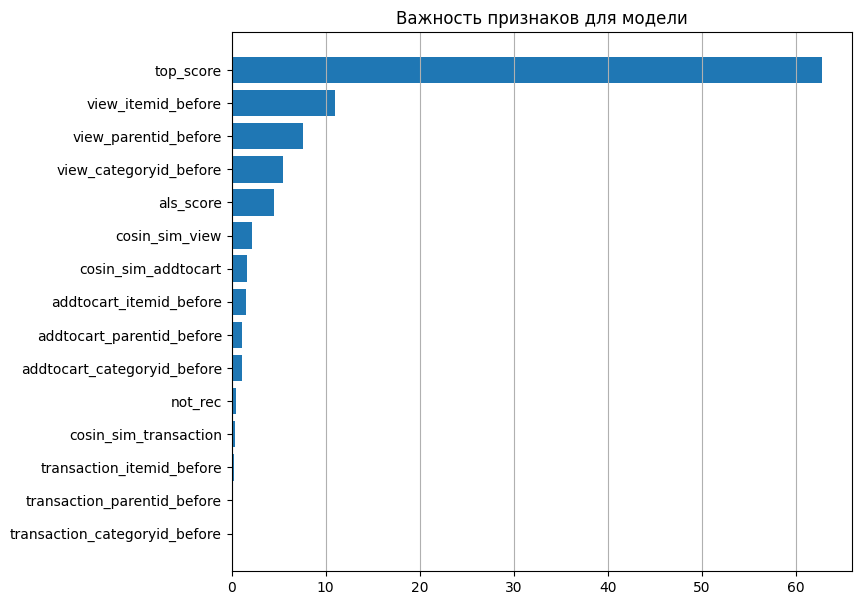

In [62]:
plt.figure(figsize=(8, 7))
plt.barh(df_weight['features'], df_weight['feature_importances'])
plt.title('Важность признаков для модели')
plt.grid(axis = 'x')
plt.show()

Как видим наибольшее влияние оказывает ниличе товара в топ 100 популярных, затем идёт просмотр либо самого товара, либо его категории, ллибо родительской категории, и только затем скор ALS.

### Выводы

В данном разделее были рассмотрены разные варианты получения рекомендаций:
- топ популярных;
- рекомендации ALS из implicit;
- рандирование полученных признаков.

Лучший результат по всем метрикам, кроме покрытия товаров показала ранжирующая модель.

## Общие выводы

В данной работе были сследованы сырые данные, выявлены закономерности и аномалии в данных. После этого данные были очищены от выбросов исохранены. На основании предобработанных данных были получены рекомендации и обучена ранжирующая модель. В ходе исследование проводилось логирование артефактов при помщи Airflow